# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad

from carve import CARVE

In [3]:
SUBSAMPLE = True
subsample_size = 0.5

In [4]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [5]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [7]:
from benchmarking_utils import gamma_quantile_approx
from case_study_plotting import (
    fragmentation_report, plot_dim_red, calculate_baseline_aris_and_plot, baseline_metrics_over_k, alluvial_compare,
    plot_label_split_counts
)

---

## 1. Pre-Process the Data

In [8]:
DATA_DIR = Path("../../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [9]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [10]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [11]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [12]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs

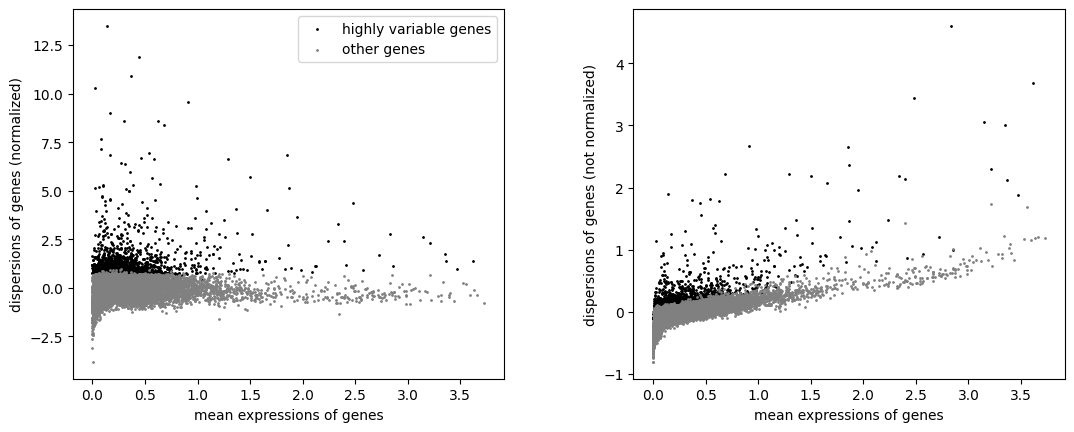

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="condition", flavor='seurat')
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var["highly_variable"]].copy()

---

## 2. Analyse Data

In [14]:
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
X = X.to_numpy()
y = pd.Series(adata.obs['condition'].values)

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")
print(f"y shape: {y.shape}")
print(f"Number of unique cell types in y: {np.unique(y)}")

X shape (cells × genes): 2,717 × 2,000
y shape: (2717,)
Number of unique cell types in y: ['d0' 'd2' 'd4' 'd7']


In [15]:
# Stratified subsampling
if SUBSAMPLE:
    if isinstance(subsample_size, float):
         subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]

    X_sub = X[idx]
    y_sub = y.loc[selected_idx]
    
    X = X_sub
    y = y_sub

    print("X shape:", X.shape)

X shape: (1358, 2000)


### 2.1 Plot PCA:

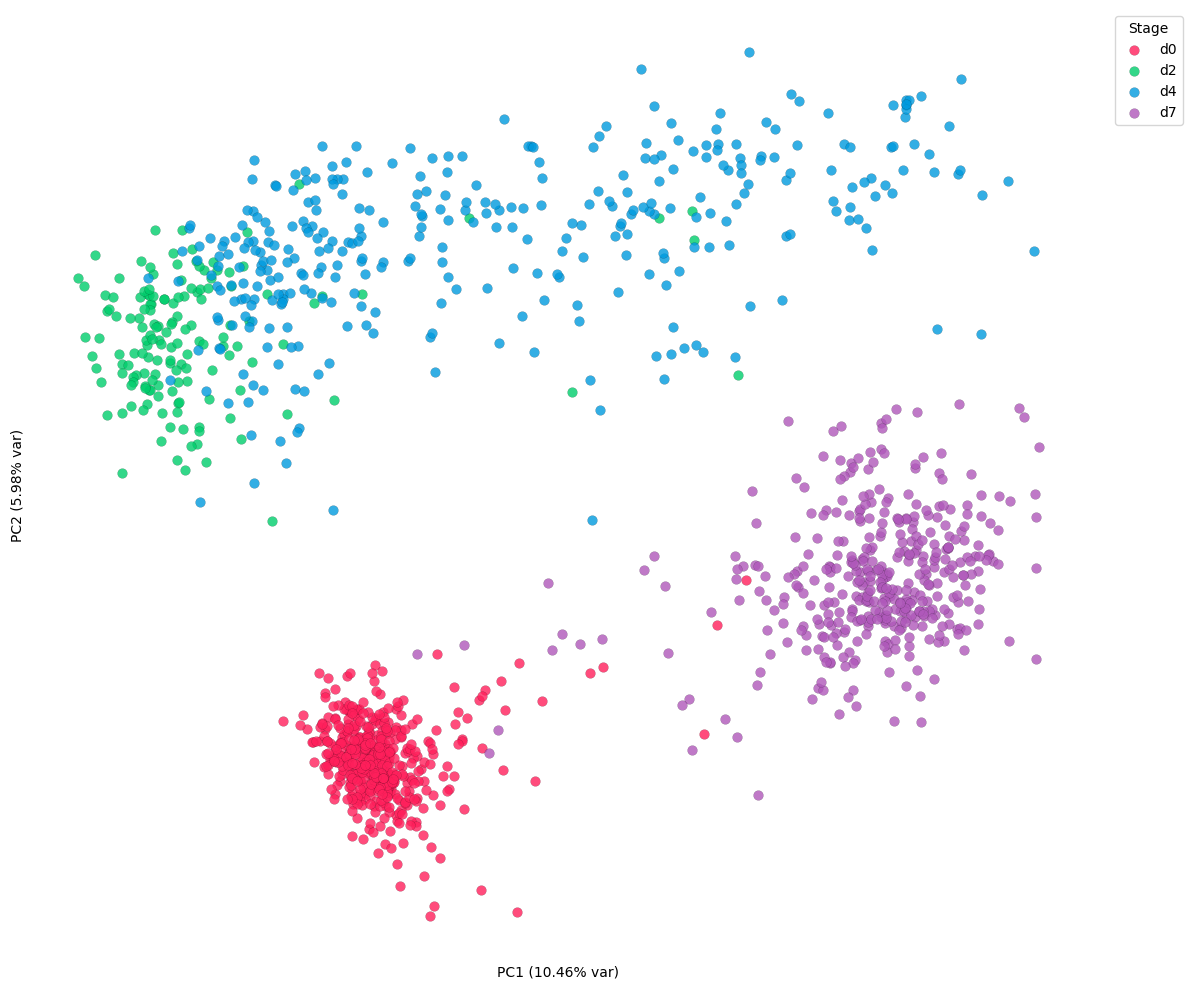

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='PC1 (10.46% var)', ylabel='PC2 (5.98% var)'>)

In [16]:
plot_dim_red(X=X, y=y, title='', legend_title="Stage")

### 2.2 Perform Clustering with "Oracle" Number of Clusters:

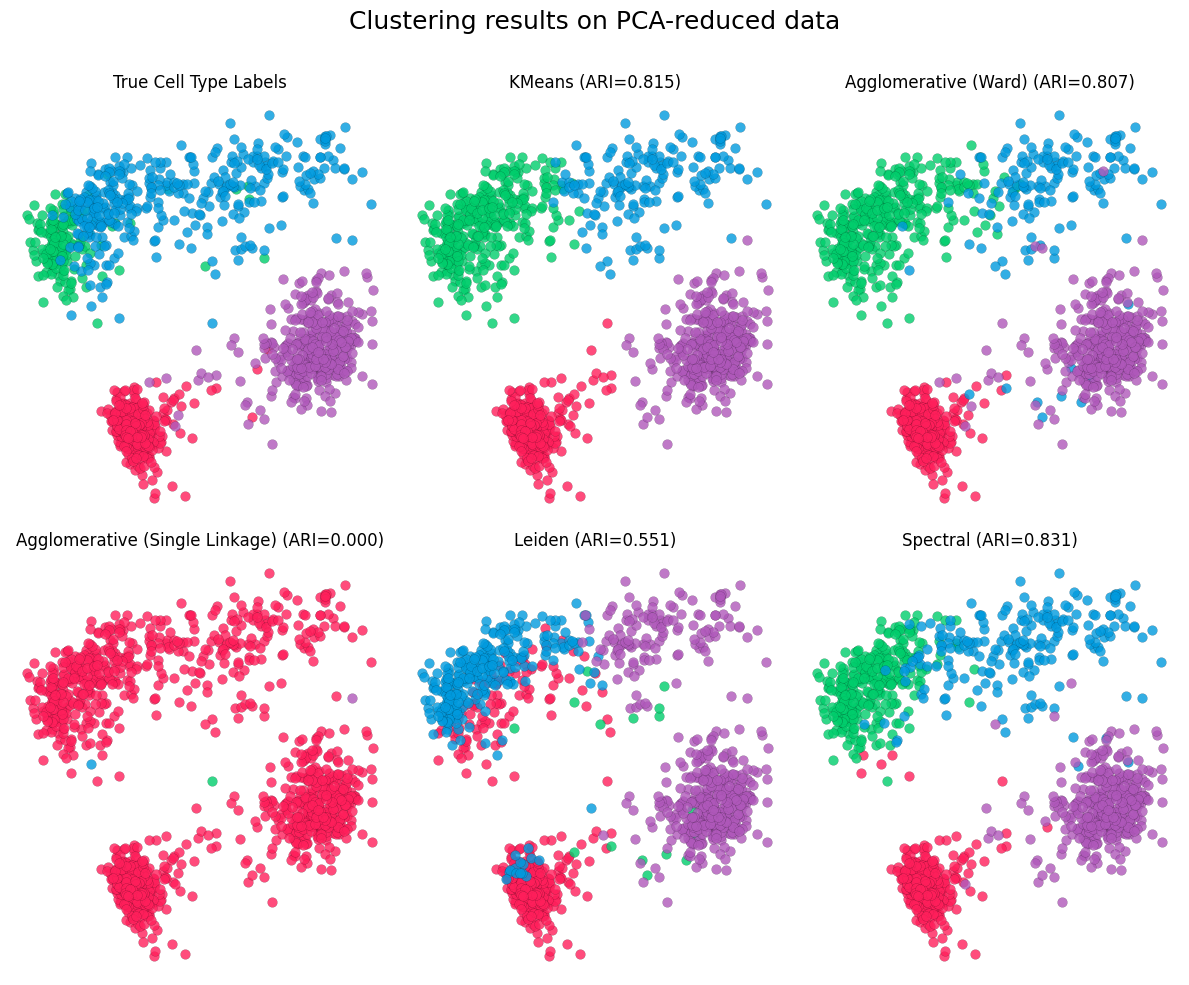

In [18]:
calculate_baseline_aris_and_plot(X=X, y=y, random_state=RANDOM_SEED)

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [25]:
K = 10
ks = list(range(2, K + 1))

gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
gamma_01  = gamma_quantile_approx(X, q=0.10, random_state=RANDOM_SEED)
gamma_05  = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

model_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]})
]


baseline selections (max metric):
  - Silhouette: k=2, score=0.1010, ari=0.3787   [Spectral (gamma=0.00206)]
  - Gap Statistic: k=10, score=1.3060, ari=0.7504   [Agglomerative (linkage=ward)]
  - DB: k=2, score=0.2522, ari=0.3787   [Spectral (gamma=0.00177)]
  - CH: k=2, score=137.3124, ari=0.3787   [Spectral (gamma=0.00206)]


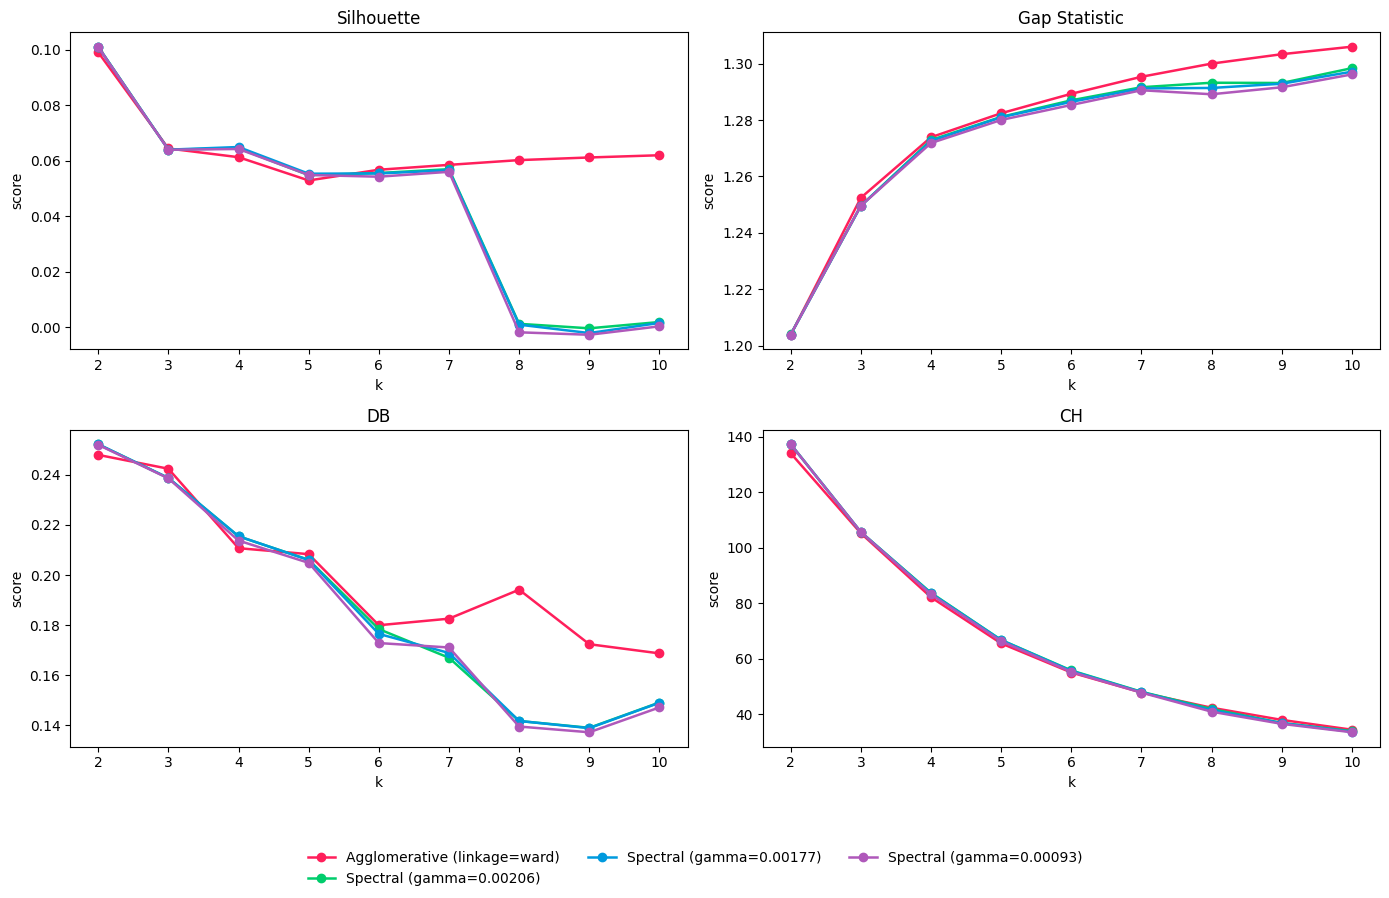

In [20]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,                       # or None if you don't have labels
    model_grids=model_grids,   # same object you pass to CARVE
    metrics=["silhouette", "gap", "DB", "CH"],
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
    ncols=2,
    figsize=(14, 9),
)

---

## 4. Run CARVE:

In [21]:
carve = CARVE(
    estimator_param_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1358
[CARVE] n_features         : 2000
[CARVE] n_clusters         : 10
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 36
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/36] est=AgglomerativeClustering n_clusters=2 | ARI_stab=0.841±0.014  ARI_gen=0.834±0.015  ARI_avg=0.837±0.012
[CARVE] [2/36] est=AgglomerativeClustering n_clusters=3 | ARI_stab=0.887±0.009  ARI_gen=0.887±0.010  ARI_avg=0.887±0.008
[CARVE] [3/36] est=AgglomerativeClustering n_clusters=4 | ARI_stab=0.935±0.002  ARI_gen=0.944±0.003  ARI_avg=0.939±0.002
[CARVE] [4/36] est=AgglomerativeClustering n_clusters=5 | ARI_stab=0.905±0.005  ARI_gen=0.884±0.005  ARI_avg=0.895±0.004
[CARVE] [5/36] est

,n_clusters,10
,n_resamples,100
,subsample_ratio,0.8
,estimator_param_grids,"[(<class 'sklea...veClustering'>, ...), (<class 'sklea...alClustering'>, ...)]"
,normalization_options,None
,dim_reduction_options,None
,reference_labels,"array([0, 1, 0, ..., 2, 3, 3])"
,n_jobs,10
,random_state,42
,verbose,1


In [24]:
carve.save("carve_klein.carve")

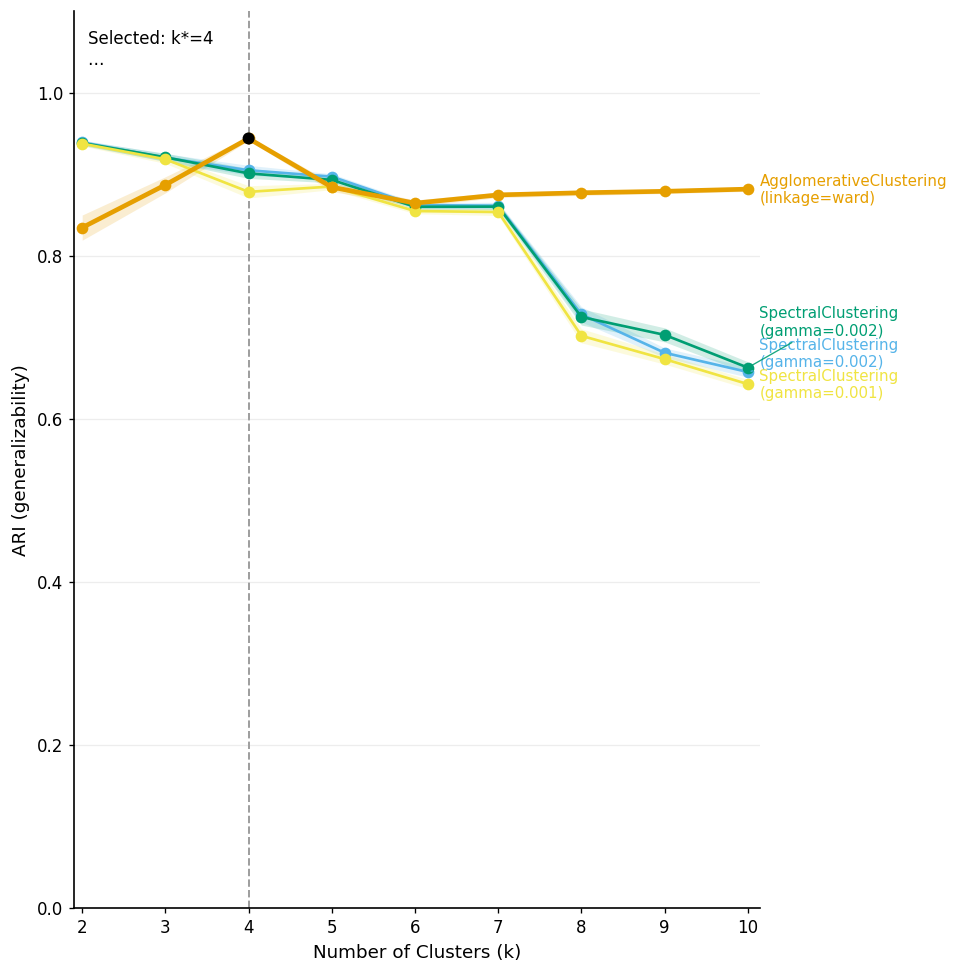

In [22]:
carve.plot_metric_over_k(measure='ari_generalizability', rule='1se', interactive=False)

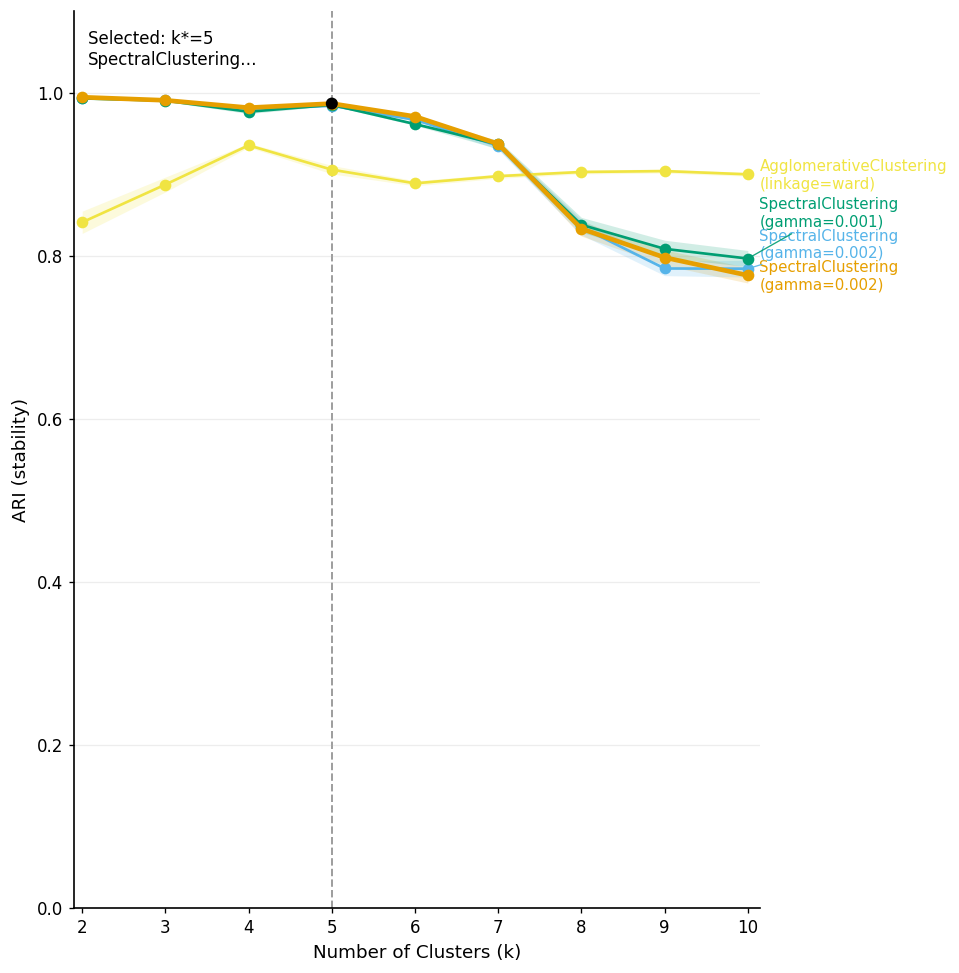

In [23]:
carve.plot_metric_over_k(measure='ari_stability', rule='quantile', interactive=False)

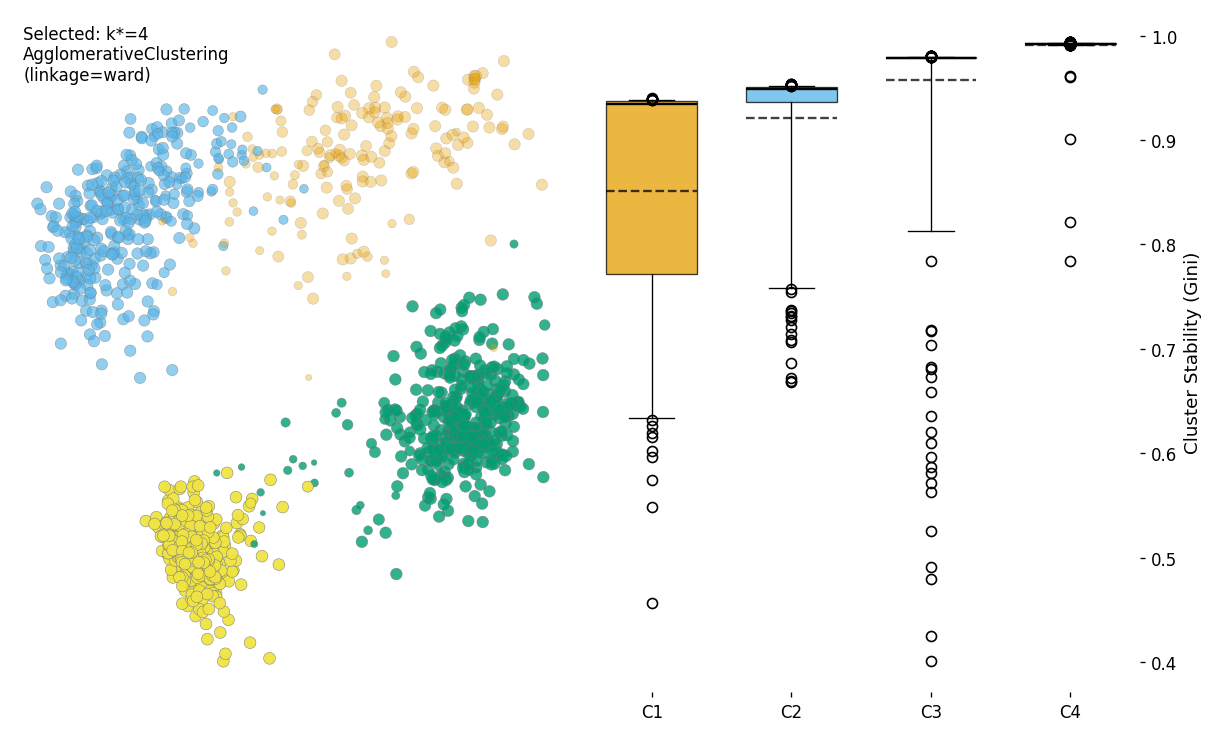

In [56]:
carve.plot_cluster_summary(measure='generalizability', rule='1se')

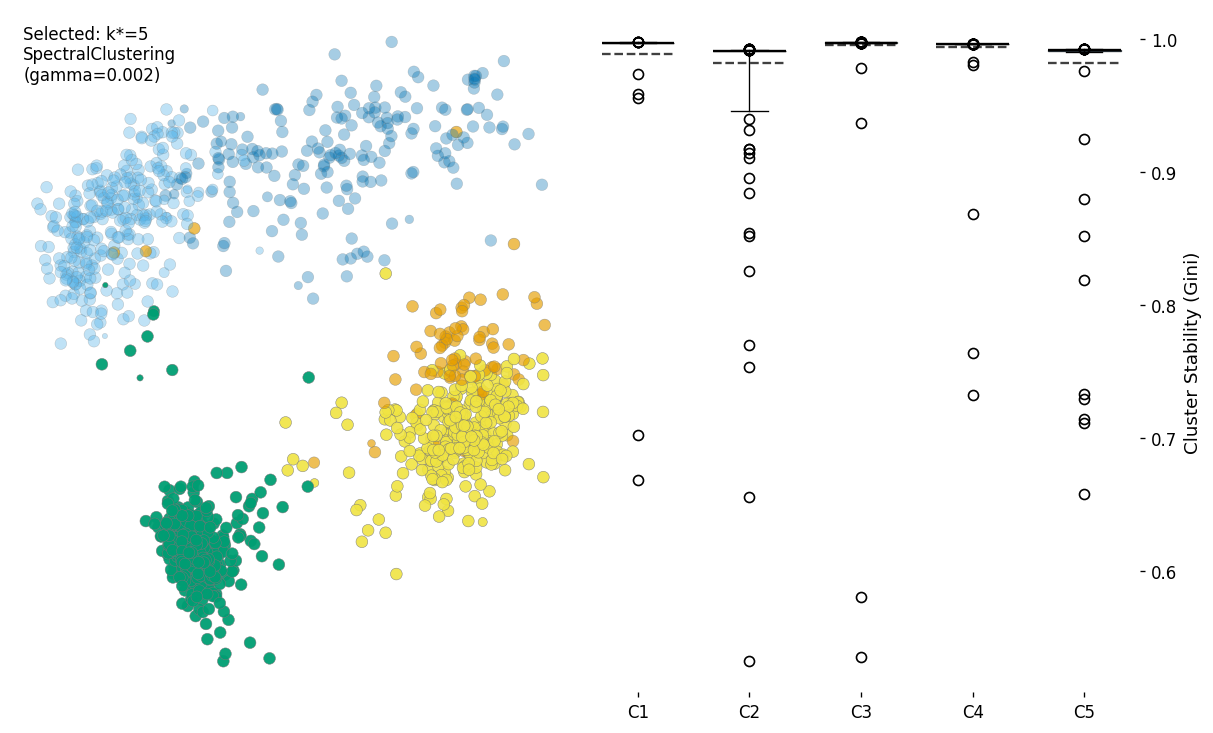

In [57]:
carve.plot_cluster_summary(measure='stability', rule='quantile')

In [20]:
# Spectral labels with gamma=5%-quantile of sqeuclidean distances, as suggested by silhouette
silhouette_labels = SpectralClustering(n_clusters=2, gamma=gamma_005, random_state=RANDOM_SEED).fit_predict(X)

# Spectral, k=7 –– as suggested by CARVE generalizability 
# carve_labels = carve.get_labels(measure="generalizability", rule="1se")
carve_labels = AgglomerativeClustering(n_clusters=4, linkage="ward").fit_predict(X)

fig = alluvial_compare(
    y_true=y,
    left_labels=carve_labels,
    right_labels=silhouette_labels,
    left_title="CARVE",
    right_title="Silhouette",
    true_title="True Label",
    palette_name="tab10",
    link_alpha=0.35, 
    font_size=18, 
    title_y=1.2
)

fig.show()


---

## 5) Motivational Plots:

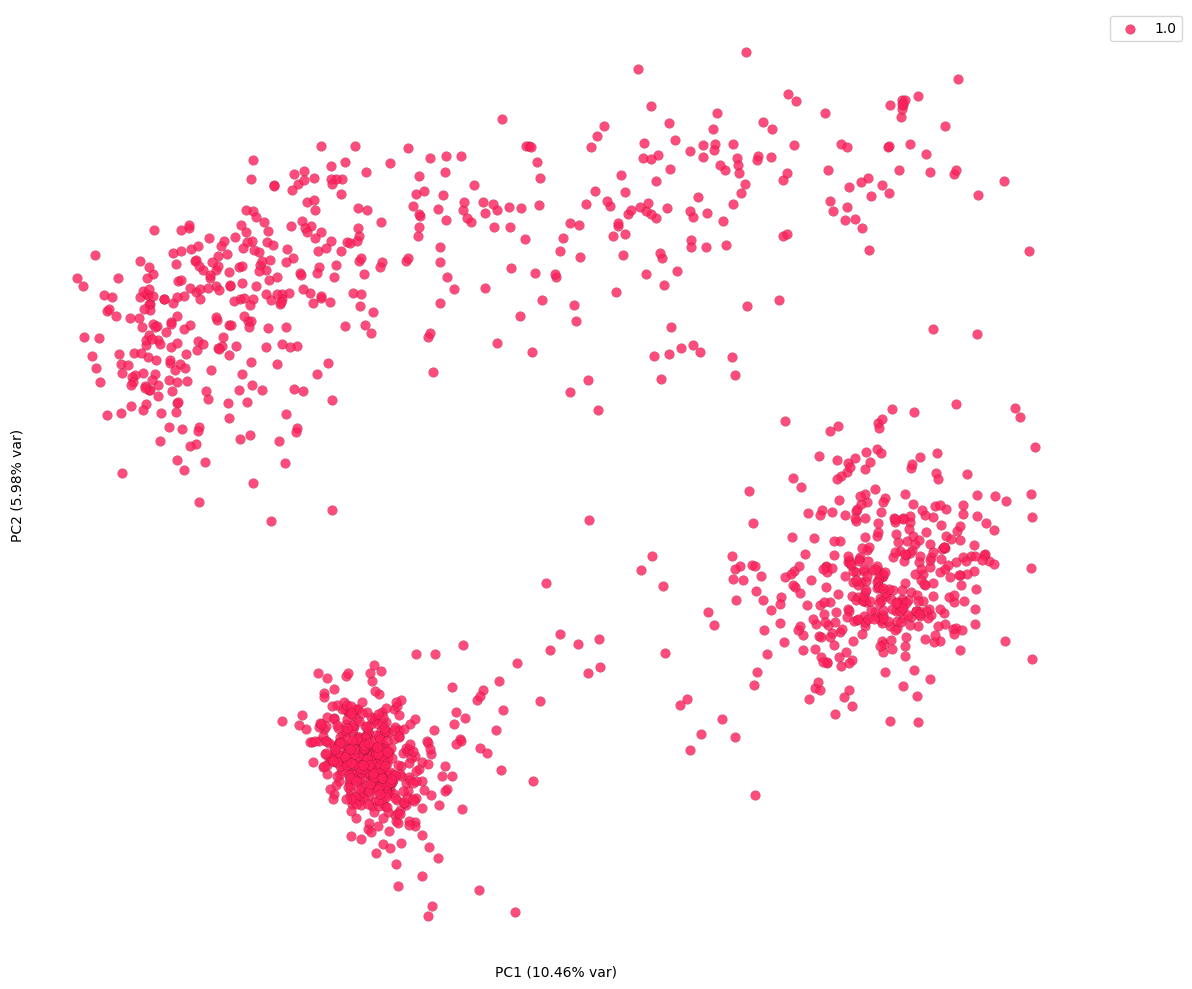

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='PC1 (10.46% var)', ylabel='PC2 (5.98% var)'>)

In [31]:
plot_dim_red(X=X, y=np.ones(X.shape[0]), title='', legend_title="")

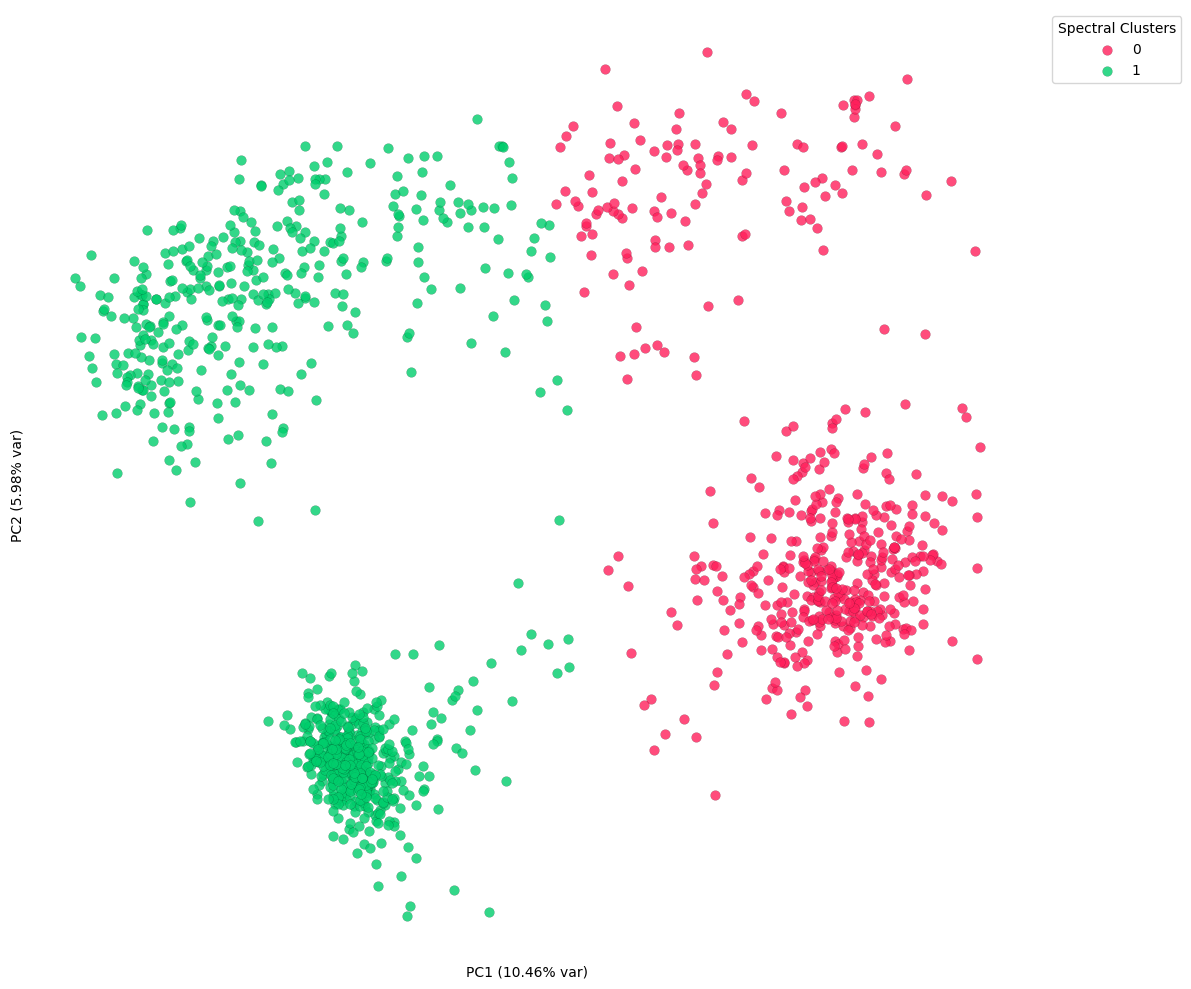

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='PC1 (10.46% var)', ylabel='PC2 (5.98% var)'>)

In [30]:
labels_3 = SpectralClustering(n_clusters=2, gamma=gamma_005, random_state=RANDOM_SEED).fit_predict(X)

plot_dim_red(X=X, y=labels_3, title='', legend_title="Spectral Clusters")

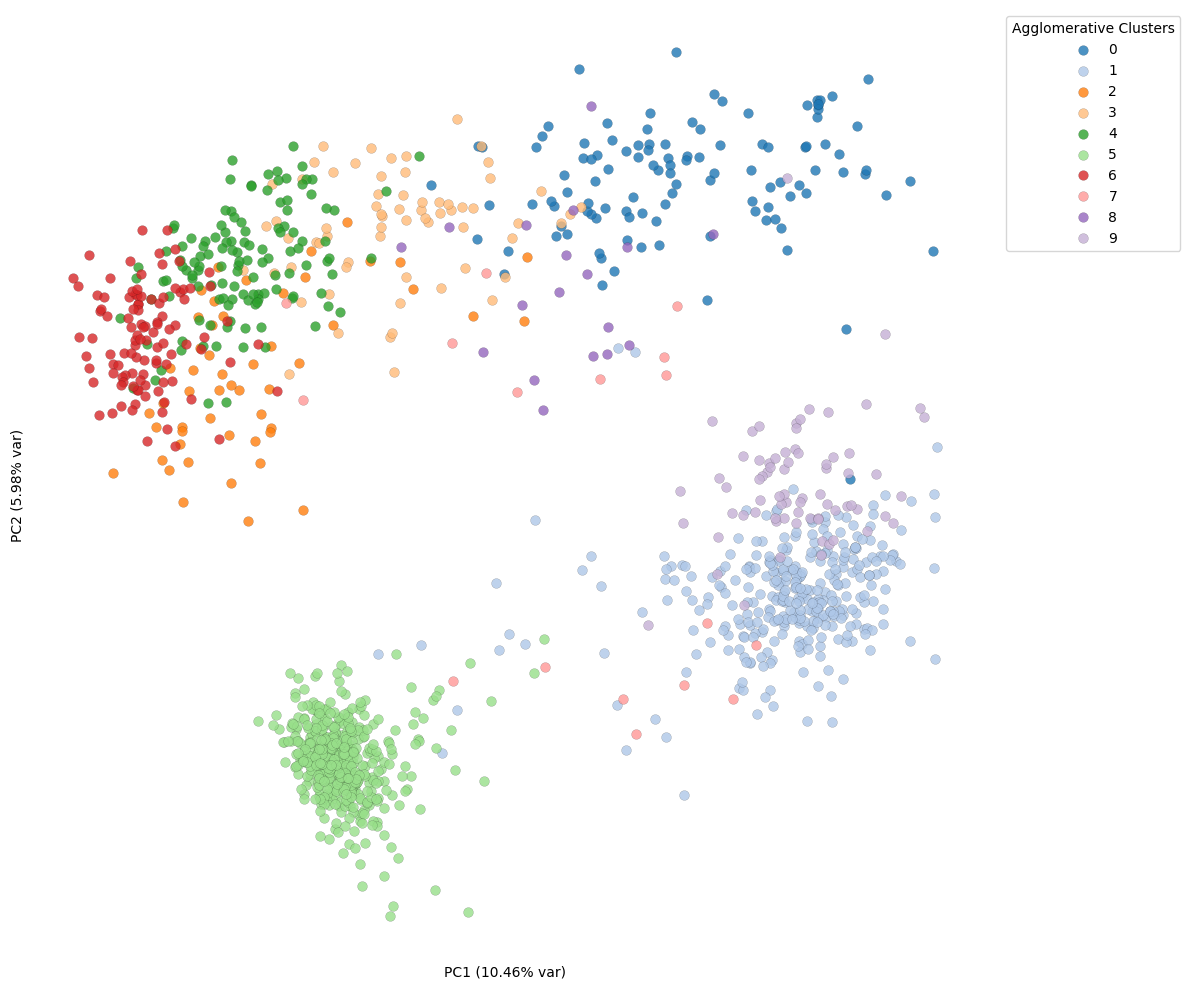

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='PC1 (10.46% var)', ylabel='PC2 (5.98% var)'>)

In [29]:
labels_10 = AgglomerativeClustering(n_clusters=10, linkage='ward').fit_predict(X)

plot_dim_red(X=X, y=labels_10, title='', legend_title="Agglomerative Clusters")

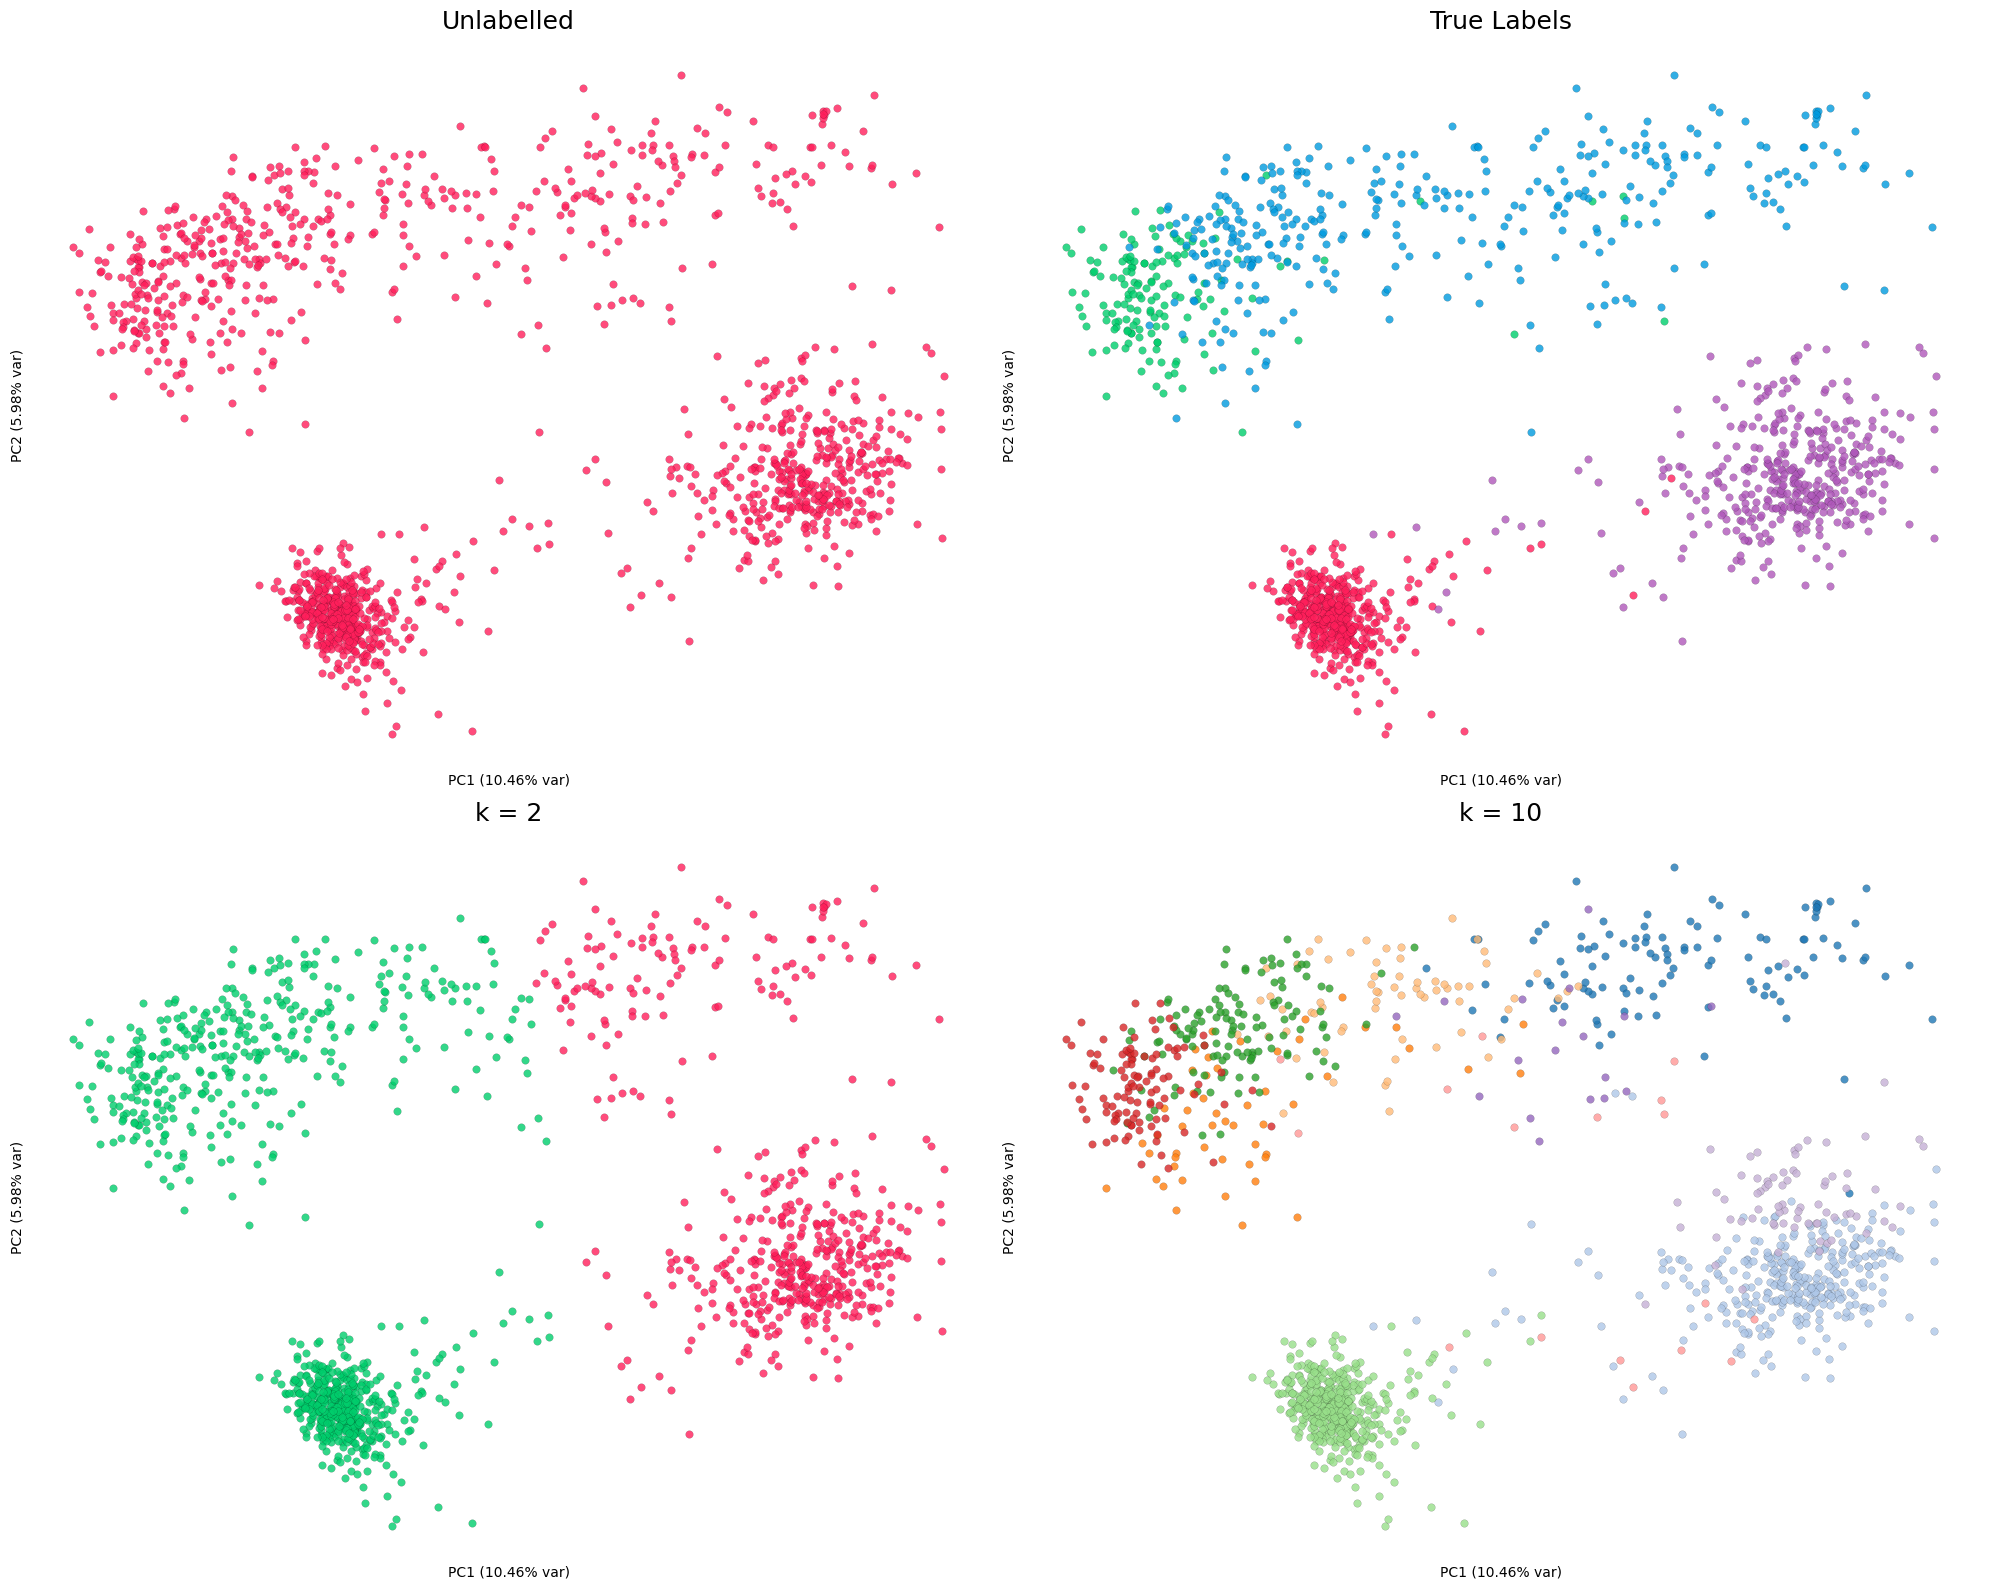

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

plot_dim_red(X=X, y=np.ones(X.shape[0]), title="", legend_title="",
             show_legend=False, ax=axes[0, 0], show=False, s=30)
axes[0, 0].set_title("Unlabelled", fontsize=18, pad=10)

plot_dim_red(X=X, y=y, title="", legend_title="Stage",
             show_legend=False, ax=axes[0, 1], show=False, s=30)
axes[0, 1].set_title("True Labels", fontsize=18, pad=10)

plot_dim_red(X=X, y=labels_3, title="", legend_title="Spectral Clusters",
             show_legend=False, ax=axes[1, 0], show=False, s=30)
axes[1, 0].set_title("k = 2", fontsize=18, pad=10)

plot_dim_red(X=X, y=labels_10, title="", legend_title="Agglomerative Clusters",
             show_legend=False, ax=axes[1, 1], show=False, s=30)
axes[1, 1].set_title("k = 10", fontsize=18, pad=10)

fig.tight_layout()
plt.show()

---